In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import MinMaxScaler



In [2]:
sns.set_theme(style="whitegrid", palette="viridis", font_scale=1.2)

In [3]:
import pandas as pd

df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
print(df.info())
# دریافت اطلاعات کلی شامل نوع متغیرها و تعداد داده‌های غیرخالی

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [5]:
display(df.describe())
# دریافت آماره‌های توصیفی برای ستون‌های عددی (مثل میانگین، حداقل، حداکثر)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
print(df.isnull().sum())
# بررسی تعداد مقادیر گمشده در هر ستون

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [7]:
# ببین هر ستون چند تا صفر دارد
print("تعداد صفرها در هر ستون:")
print((df == 0).sum())

تعداد صفرها در هر ستون:
Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [8]:

total_rows = len(df)

problems = {
    'Glucose': 5,
    'BloodPressure': 35,
    'SkinThickness': 227,
    'Insulin': 374,
    'BMI': 11
}

for col, count in problems.items():
    percent = (count / total_rows) * 100
    print(f"{col}: {count} صفر = {percent:.1f}٪ از کل داده‌ها")

Glucose: 5 صفر = 0.7٪ از کل داده‌ها
BloodPressure: 35 صفر = 4.6٪ از کل داده‌ها
SkinThickness: 227 صفر = 29.6٪ از کل داده‌ها
Insulin: 374 صفر = 48.7٪ از کل داده‌ها
BMI: 11 صفر = 1.4٪ از کل داده‌ها


In [9]:
df = df[df['Glucose'] != 0]
df = df[df['BMI'] != 0]
print(f"بعد از حذف Glucose و BMI: {len(df)} ردیف")


بعد از حذف Glucose و BMI: 752 ردیف


In [10]:
df_original = pd.read_csv('diabetes.csv')

In [11]:
median_skin = df[df['SkinThickness'] > 0]['SkinThickness'].median()
df['SkinThickness'] = df['SkinThickness'].replace(0, median_skin)
print(f"ضخامت پوست: صفرها با {median_skin} جایگزین شدند")

ضخامت پوست: صفرها با 29.0 جایگزین شدند


In [12]:
median_bp = df[df['BloodPressure'] > 0]['BloodPressure'].median() 
df['BloodPressure'] = df['BloodPressure'].replace(0, median_bp)

In [13]:

df_clean = df.copy()
df_clean['Insulin'] = df_clean['Insulin'].replace(0, np.nan)

relevant_cols = ['Glucose', 'BMI', 'Age', 'Pregnancies', 'BloodPressure', 'Insulin']
df_relevant = df_clean[relevant_cols]


imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(df_relevant), columns=relevant_cols)

# جایگزینی ستون Insulin
df['Insulin'] = df_imputed['Insulin']

print(" Insulin با KNNImputer پر شد")
print(f"تعداد صفر باقیمانده: {(df['Insulin'] == 0).sum()}")
print(f"میانگین جدید Insulin: {df['Insulin'].mean():.1f}")

 Insulin با KNNImputer پر شد
تعداد صفر باقیمانده: 0
میانگین جدید Insulin: 155.4


In [19]:
# میانه Insulin را از سطرهایی که مقدار دارند حساب کن
median_insulin = df['Insulin'].median()

# NaNها را با میانه پر کن
df['Insulin'] = df['Insulin'].fillna(median_insulin)


print(f"تعداد NaN بعد از پر کردن: {df['Insulin'].isna().sum()}")
print(f"میانه استفاده شده: {median_insulin}")

تعداد NaN بعد از پر کردن: 0
میانه استفاده شده: 135.0


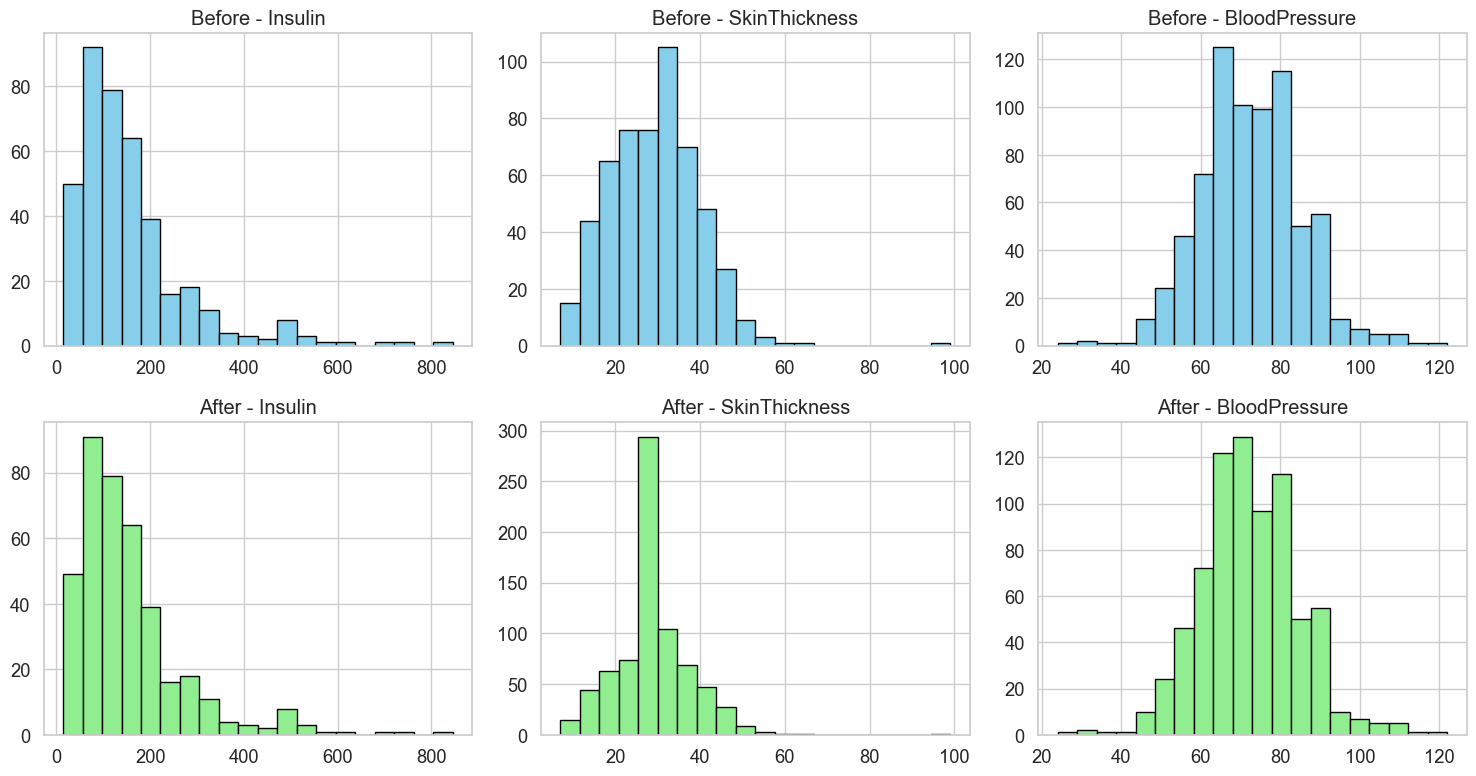

In [15]:
columns = ['Insulin', 'SkinThickness', 'BloodPressure']
plt.figure(figsize=(15, 8))

for i, col in enumerate(columns):
    # ۱. قبل از پر کردن داده‌ها (حذف صفرهای غلط برای نمایش درست توزیع اولیه)
    plt.subplot(2, 3, i + 1)
    # داده‌های بزرگتر از صفر رو می‌کشیم تا صفرهای غلط نمودار رو خراب نکنن
    plt.hist(df_original[df_original[col] > 0][col], bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Before - {col}')
    
    # ۲. بعد از پر کردن داده‌ها
    plt.subplot(2, 3, i + 4)
    # رسم داده‌های پاک‌سازی شده (df_clean یا df)
    plt.hist(df_clean[col], bins=20, color='lightgreen', edgecolor='black')
    plt.title(f'After - {col}')

plt.tight_layout()
plt.show()

In [ ]:
# ۱. ساختن X و y از روی جدول تمیز شده (df)
X = df.drop('Outcome', axis=1)
y = df['Outcome']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
from sklearn.metrics import roc_curve

# ۱. محاسبه احتمالات برای داده‌های تست
probs = rf_best.predict_proba(X_test_scaled)[:, 1]

# ۲. گرفتن نرخ مثبت‌های واقعی (tpr)، مثبت‌های کاذب (fpr) و تمام آستانه‌ها (thresholds)
fpr, tpr, thresholds = roc_curve(y_test, probs)

# ۳. فرمول یافتن بهترین آستانه (شاخص یودن)
# این فرمول فاصله بین تشخیص درست و تشخیص غلط را به حداکثر می‌رساند
optimal_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[optimal_idx]

print(f"بهترین آستانه پیدا شده: {best_threshold:.2f}")

بهترین آستانه پیدا شده: 0.25


In [23]:

rf_best = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

rf_best.fit(X_train_scaled, y_train)

probs_best = rf_best.predict_proba(X_test_scaled)[:, 1]

y_pred_best = (probs_best >= 0.25).astype(int)

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.89      0.71      0.79        98
           1       0.61      0.83      0.70        53

    accuracy                           0.75       151
   macro avg       0.75      0.77      0.75       151
weighted avg       0.79      0.75      0.76       151



In [25]:
accuracy = accuracy_score(y_test, y_pred_best)
print(f"دقت کلی مدل: {accuracy:.2%}")

دقت کلی مدل: 75.50%


In [26]:
def test(p, g, bp, s, i, bmi, d, age):
    
    features = [[p, g, bp, s, i, bmi, d, age]]
    
    
    features_scaled = scaler.transform(features)
    
   
    prob = rf_best.predict_proba(features_scaled)[0][1]
    
    return f"{'دیابتی' if prob >= 0.25 else 'سالم'} ({prob:.1%})"

# مثال برای تست
print(test(2, 140, 72, 25, 90, 32, 0.5, 45))

دیابتی (71.0%)


c:\Program Files\Python38\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


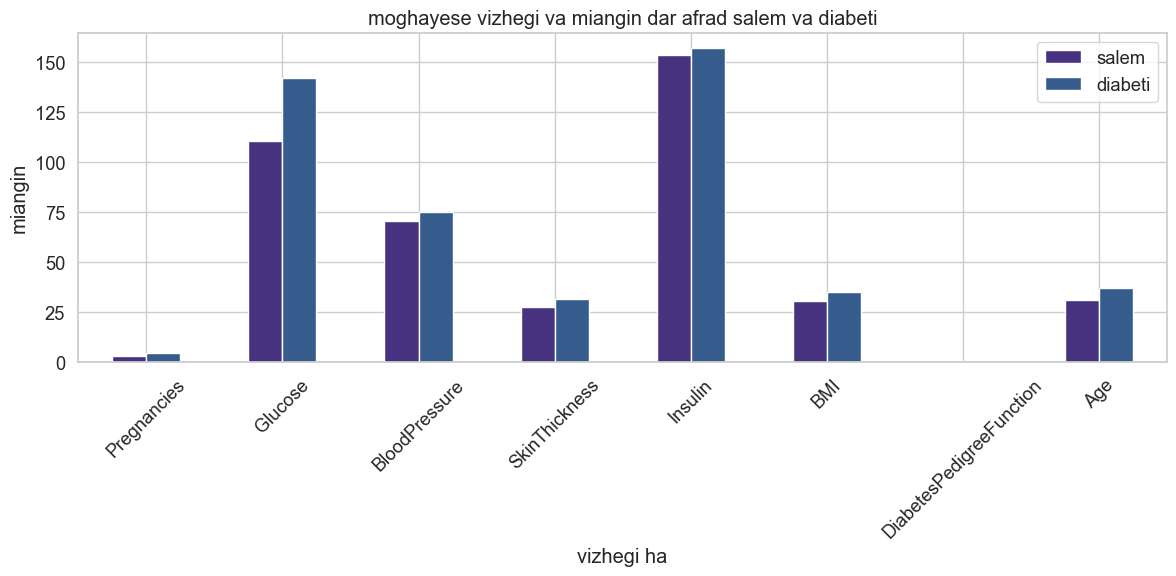

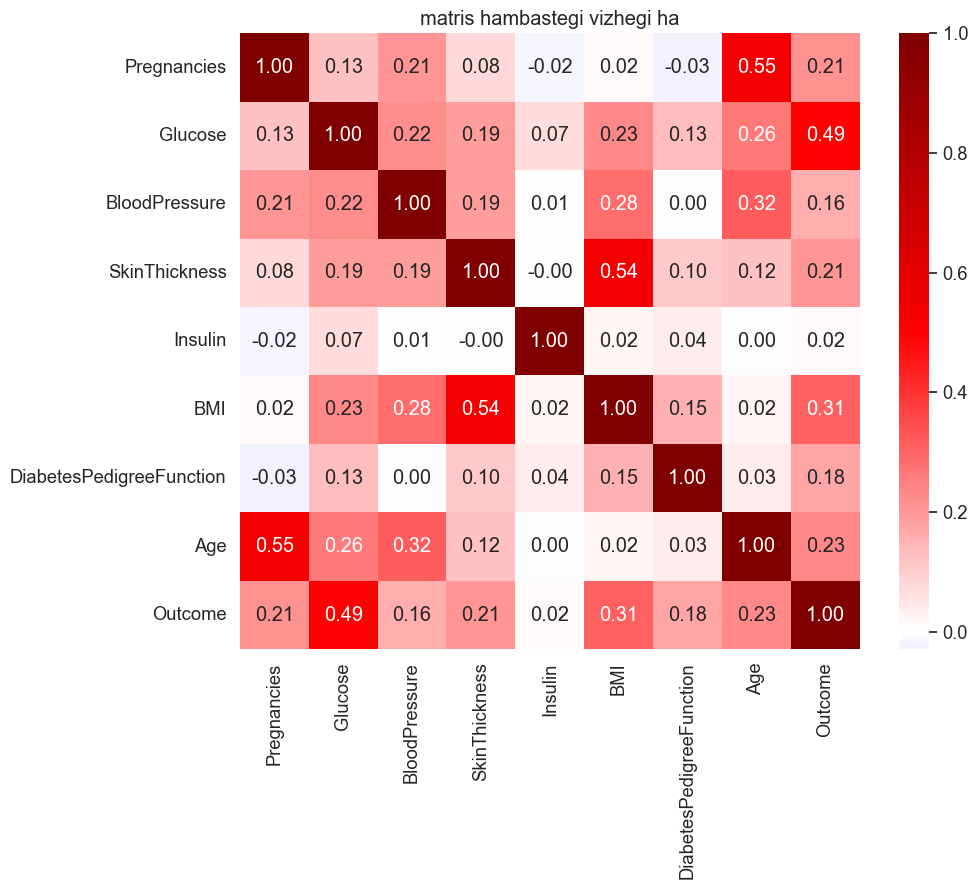

\mohem tarin vizhegi hay mortabet ba diabet :
Outcome                     1.000000
Glucose                     0.494190
BMI                         0.309884
Age                         0.232734
Pregnancies                 0.213371
SkinThickness               0.211854
DiabetesPedigreeFunction    0.178052
BloodPressure               0.162308
Insulin                     0.016230
Name: Outcome, dtype: float64


In [27]:

# 1. مقایسه میانگین‌ها
mean_values = df.groupby('Outcome').mean()
mean_values.T.plot(kind='bar', figsize=(12, 6))
plt.title('moghayese vizhegi va miangin dar afrad salem va diabeti')
plt.xlabel('vizhegi ha')
plt.ylabel('miangin')
plt.legend(['salem', 'diabeti'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. ماتریس همبستگی
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='seismic', center=0, fmt='.2f')
plt.title('matris hambastegi vizhegi ha')
plt.show()

# 3. مهم‌ترین ویژگی‌ها
print("\mohem tarin vizhegi hay mortabet ba diabet :")
print(df.corr()['Outcome'].sort_values(ascending=False))

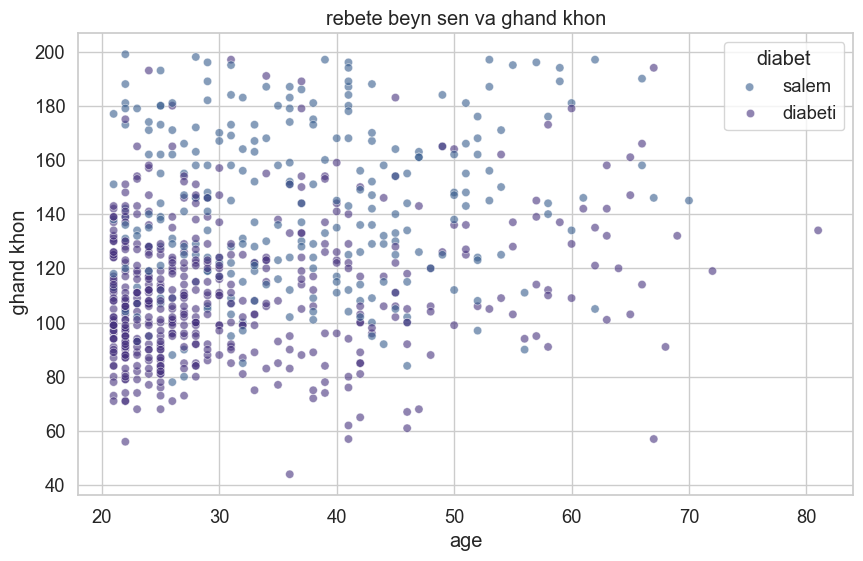

In [28]:
# نمودار پراکندگی: سن در مقابل قند خون
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Glucose', hue='Outcome', alpha=0.6)
plt.title('rebete beyn sen va ghand khon')
plt.xlabel('age')
plt.ylabel(' ghand khon')
plt.legend(title='diabet', labels=['salem', 'diabeti'])
plt.show()